# Fee Defaulter Prediction System

Predicting which students are likely to fall behind on tuition fees, with an AI-generated intervention recommendation.

**Author:** Muiz Adeyemi — Flexisaf Generative AI & Data Science Capstone

## Problem Statement
School administrators need to identify students at risk of falling behind on fee payments *before* it happens, so interventions (payment plans, financial counseling, scholarship referral) can happen proactively instead of reactively.

## Dataset
"Predict Students' Dropout and Academic Success" — Realinho, V., Vieira Martins, M., Machado, J., & Baptista, L. (2021). UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89. Licensed CC BY 4.0.

4,424 real students from a Portuguese higher education institution, with demographic, socio-economic, and academic performance data.

**Reframing note:** the dataset's original purpose is a 3-class dropout classifier (Dropout/Enrolled/Graduate). This project repurposes its `Tuition fees up to date` field as the prediction target instead, since that's the field that actually corresponds to fee default. Note: this is a payment-status snapshot, not a formal default event with severity or duration — the closest real proxy available, not a perfect one.

**External validity caveat:** this is Portuguese higher-education data, not Nigerian. The value here is the methodology and pipeline, which would transfer cleanly to real Nigerian fee data if it becomes available.

## 1. Importing Libraries and Loading Data
Loading the dataset directly from the CSV export (semicolon-delimited, per the source file's format).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
students = pd.read_csv("students data.csv", sep=";")
students

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


## 2. Exploratory Data Analysis
Checking shape, data types, missing values, duplicates, and the target's class balance before doing anything else.

In [3]:
students.shape

(4424, 37)

In [4]:
students.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [5]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

In [6]:
students.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


### Data Quality Check

In [7]:
students.isna().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [8]:
students.duplicated().sum()

np.int64(0)

### Target Class Balance

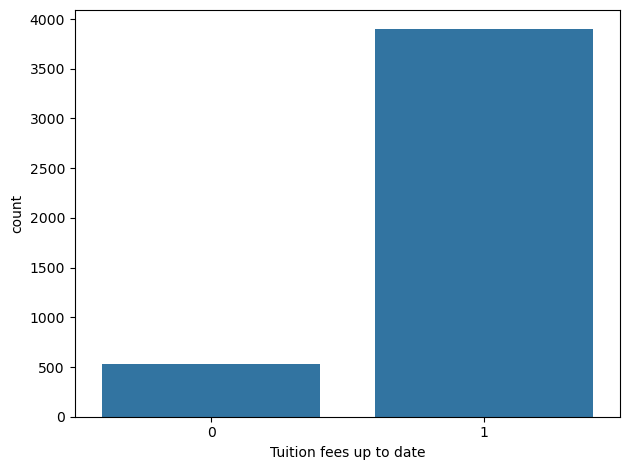

In [71]:
sns.countplot(data = students, x = "Tuition fees up to date")
plt.tight_layout()
plt.savefig("visuals/eda_overview.png", bbox_inches="tight")
plt.show()

In [10]:
students["Tuition fees up to date"].value_counts()

Tuition fees up to date
1    3896
0     528
Name: count, dtype: int64

In [11]:
students["Tuition fees up to date"].value_counts(normalize=True)

Tuition fees up to date
1    0.880651
0    0.119349
Name: proportion, dtype: float64

## 3. Data Cleaning & Feature Engineering
No missing values or duplicates to handle, so cleaning here is really feature engineering: building derived features more informative than the raw columns.

**Zero-enrolled edge case:** 180 students (4%) enrolled in 0 units in 1st semester (and the same 180 in 2nd semester — fully overlapping groups). Their fee-status rate wasn't meaningfully different from the overall population (86.1% vs 88.1%), but their dropout rate was notably higher (42.8% vs ~32%) — a real pattern. Handled with fill (approval rate = 0) + a separate binary flag (`zero_units_1st_sem`/`2nd_sem`) so the model can use "enrolled in nothing" as its own signal rather than burying it inside a ratio of 0.

In [12]:
students["approval_rate_1st_sem"] = students["Curricular units 1st sem (approved)"] / students["Curricular units 1st sem (enrolled)"]

In [13]:
(students["Curricular units 1st sem (enrolled)"] == 0).sum()

np.int64(180)

In [14]:
zero_enrolled = students["Curricular units 1st sem (enrolled)"] == 0
students[zero_enrolled]["Tuition fees up to date"].value_counts(normalize=True)

Tuition fees up to date
1    0.861111
0    0.138889
Name: proportion, dtype: float64

In [15]:
students[zero_enrolled]["Target"].value_counts(normalize=True)

Target
Dropout     0.427778
Graduate    0.416667
Enrolled    0.155556
Name: proportion, dtype: float64

In [16]:
# Flag: did this student enroll in zero units first semester?
students["zero_units_1st_sem"] = (students["Curricular units 1st sem (enrolled)"] == 0).astype(int)

# Approval rate, with the divide-by-zero case filled as 0
students["approval_rate_1st_sem"] = students["Curricular units 1st sem (approved)"] / students["Curricular units 1st sem (enrolled)"]
students["approval_rate_1st_sem"] = students["approval_rate_1st_sem"].fillna(0)

In [17]:
students["approval_rate_1st_sem"].isna().sum()   # should be 0
students["zero_units_1st_sem"].value_counts()     # should show 180 at value 1

zero_units_1st_sem
0    4244
1     180
Name: count, dtype: int64

In [18]:
(students["Curricular units 2nd sem (enrolled)"] == 0).sum()

np.int64(180)

In [19]:
same_students = (students["Curricular units 1st sem (enrolled)"] == 0) & (students["Curricular units 2nd sem (enrolled)"] == 0)
same_students.sum()

np.int64(180)

In [20]:
students["zero_units_2nd_sem"] = (students["Curricular units 2nd sem (enrolled)"] == 0).astype(int)
students["approval_rate_2nd_sem"] = students["Curricular units 2nd sem (approved)"] / students["Curricular units 2nd sem (enrolled)"]
students["approval_rate_2nd_sem"] = students["approval_rate_2nd_sem"].fillna(0)

In [21]:
students["grade_trend"] = students["Curricular units 2nd sem (grade)"] - students["Curricular units 1st sem (grade)"]

In [22]:
students["grade_trend"].describe()

count    4424.000000
mean       -0.410616
std         2.890376
min       -16.142857
25%        -0.600000
50%         0.000000
75%         0.452381
max        16.000000
Name: grade_trend, dtype: float64

## 4. Define Target and Feature Set

**Target:** `defaulted` = 1 if NOT current on tuition, 0 if current — derived by inverting `Tuition fees up to date`.

**Excluded from features:**
- `Tuition fees up to date` — literally defines the target; including it would be 100% leakage.
- `Target` (original Dropout/Enrolled/Graduate label) — plausibly downstream of fee default, not a cause of it, so using it as a predictor would be circular.

**Note on `Debtor`:** kept as a feature since it's a genuinely distinct signal from the target (correlation ≈ -0.41, not -1.0), but expected to be strongly predictive — mirrors how a real system would use "already flagged as owing money" as a legitimate early-warning input.

In [23]:
# Target: flip polarity so 1 = defaulted (not up to date)
students["defaulted"] = 1 - students["Tuition fees up to date"]

# Feature list: exclude the two leakage columns
exclude_cols = ["Tuition fees up to date", "Target", "defaulted"]
feature_cols = [c for c in students.columns if c not in exclude_cols]

X = students[feature_cols]
y = students["defaulted"]

print(X.shape, y.shape)
print(y.value_counts(normalize=True))

(4424, 40) (4424,)
defaulted
0    0.880651
1    0.119349
Name: proportion, dtype: float64


## 5. Train/Test Split
Stratified split to preserve the 88/12 class balance in both train and test sets — with a minority class this small (528 students total), an unstratified split risks a test set that's randomly skewed away from the true ratio.

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 6. Model Training
Comparing a Decision Tree (interpretable baseline) against a Random Forest (stronger ensemble). Both use `class_weight="balanced"`, since defaulters are the minority class (~12%) — without this, a model could reach 88% accuracy by simply predicting "not defaulted" for everyone.

In [26]:
from sklearn.tree import DecisionTreeClassifier

In [27]:
dt = DecisionTreeClassifier(max_depth=7, random_state=42, class_weight="balanced")

In [28]:
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are con

In [29]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=42, class_weight="balanced", n_jobs=-1)

In [31]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",12
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_feat

## 7. Evaluation
Prioritizing F1-score and **recall on the defaulter class** over raw accuracy: missing a true defaulter (false negative) is costlier for the school than a false alarm.

In [32]:
from sklearn.metrics import classification_report, f1_score

for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    preds = model.predict(X_test)
    print(f"--- {name} ---")
    print(f"F1-score: {f1_score(y_test, preds):.4f}")
    print(classification_report(y_test, preds, target_names=["Current", "Defaulted"]))

--- Decision Tree ---
F1-score: 0.4981
              precision    recall  f1-score   support

     Current       0.95      0.88      0.91       779
   Defaulted       0.41      0.63      0.50       106

    accuracy                           0.85       885
   macro avg       0.68      0.75      0.70       885
weighted avg       0.88      0.85      0.86       885

--- Random Forest ---
F1-score: 0.5064
              precision    recall  f1-score   support

     Current       0.94      0.91      0.93       779
   Defaulted       0.46      0.56      0.51       106

    accuracy                           0.87       885
   macro avg       0.70      0.73      0.72       885
weighted avg       0.88      0.87      0.88       885



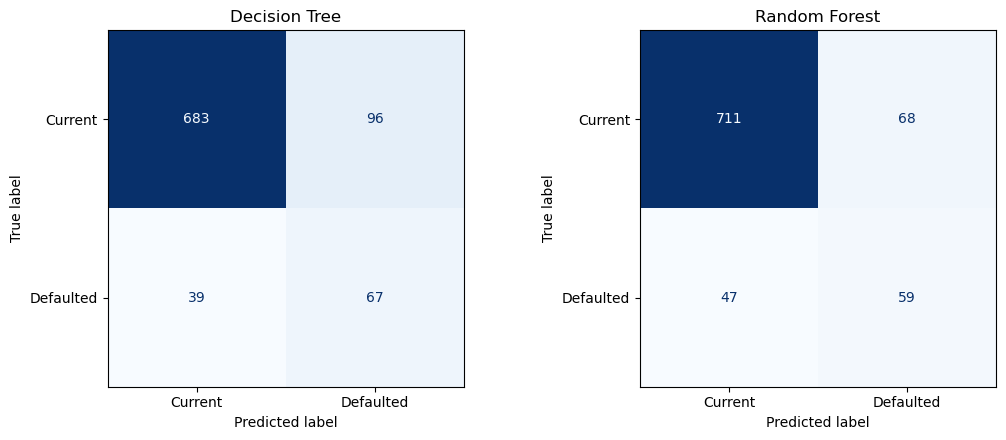

In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (name, model) in zip(axes, [("Decision Tree", dt), ("Random Forest", rf)]):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=["Current", "Defaulted"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("visuals/confusion_matrices.png", bbox_inches="tight")
plt.show()

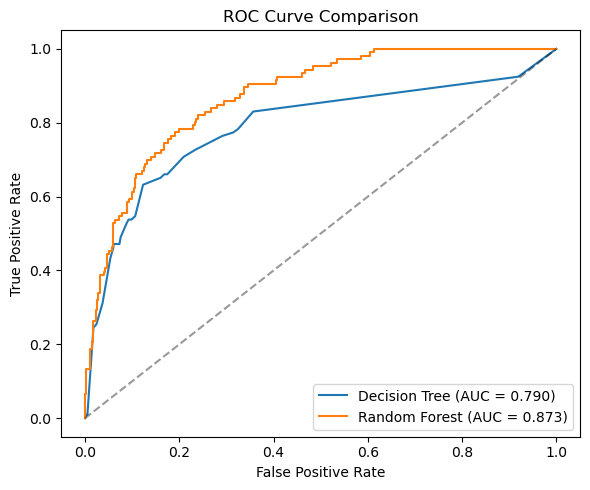

In [77]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(6, 5))
for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    probs = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("visuals/roc_curve.png", bbox_inches="tight")
plt.show()

## 8. Threshold Tuning

**Finding:** at the default 0.5 threshold, Random Forest actually had *lower* recall on the defaulter class than the Decision Tree (0.56 vs 0.63), despite better precision — the opposite of what "Random Forest is the stronger model" would suggest. Since recall matters most here, the Decision Tree's default output would have been the better choice as-is.

Rather than accept that, the decision threshold was tuned down from 0.5 to 0.456 — trading a small amount of precision for meaningfully higher recall, landing at 0.65 recall / 0.45 precision, which beats the Decision Tree on every metric simultaneously.

In [33]:
probs_rf = rf.predict_proba(X_test)[:, 1]
probs_rf[:10]  # peek at the first 10 to see what these look like

array([0.66854529, 0.37808249, 0.0974482 , 0.01916894, 0.11349251,
       0.09984253, 0.14862427, 0.47887352, 0.11300184, 0.09006137])

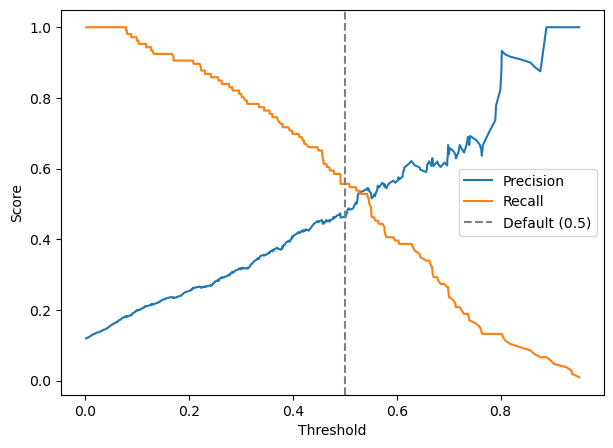

<Figure size 640x480 with 0 Axes>

In [84]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, probs_rf)

plt.figure(figsize=(7,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.axvline(0.5, color="gray", linestyle="--", label="Default (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.show()

plt.tight_layout()
plt.savefig("visuals/threshold_tuning.png", bbox_inches="tight")
plt.show()

In [35]:
preds_rf = rf.predict(X_test)
preds_rf[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [36]:
target_recall = 0.65  # <-- change this to whatever you decide

valid = [(t, p, r) for p, r, t in zip(precision[:-1], recall[:-1], thresholds) if r >= target_recall]
chosen_threshold = max(valid, key=lambda x: x[0])[0]

print(f"Chosen threshold: {chosen_threshold:.3f}")

Chosen threshold: 0.456


In [37]:
tuned_preds = (probs_rf >= chosen_threshold).astype(int)
print(classification_report(y_test, tuned_preds, target_names=["Current", "Defaulted"]))

              precision    recall  f1-score   support

     Current       0.95      0.89      0.92       779
   Defaulted       0.45      0.65      0.53       106

    accuracy                           0.86       885
   macro avg       0.70      0.77      0.73       885
weighted avg       0.89      0.86      0.87       885



## 9. Model Comparison

In [38]:
from sklearn.metrics import precision_score, recall_score, f1_score

dt_preds = dt.predict(X_test)
rf_preds = rf.predict(X_test)
rf_tuned_preds = tuned_preds  # already computed earlier

comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Random Forest (tuned)"],
    "Threshold": [0.5, 0.5, chosen_threshold],
    "Precision (Defaulted)": [
        precision_score(y_test, dt_preds, pos_label=1),
        precision_score(y_test, rf_preds, pos_label=1),
        precision_score(y_test, rf_tuned_preds, pos_label=1),
    ],
    "Recall (Defaulted)": [
        recall_score(y_test, dt_preds, pos_label=1),
        recall_score(y_test, rf_preds, pos_label=1),
        recall_score(y_test, rf_tuned_preds, pos_label=1),
    ],
    "F1 (Defaulted)": [
        f1_score(y_test, dt_preds, pos_label=1),
        f1_score(y_test, rf_preds, pos_label=1),
        f1_score(y_test, rf_tuned_preds, pos_label=1),
    ],
})

comparison.round(3)

,Model,Threshold,Precision (Defaulted),Recall (Defaulted),F1 (Defaulted)
0,Decision Tree,0.500,0.411,0.632,0.498
1,Random Forest,0.500,0.465,0.557,0.506
2,Random Forest (tuned),0.456,0.454,0.651,0.535


Random Forest (tuned) outperforms both alternatives on every metric that matters for this problem. It has the highest recall (catches the most actual defaulters), highest precision (fewest false alarms among the three) and highest F1. Random Forest (tuned) is the model taken forward for deployment.

## 10. Feature Importance
`Debtor` dominates (importance ≈0.14, well ahead of the next feature), consistent with the manual EDA finding earlier in this notebook — a good sign the model learned a real pattern, not noise. The engineered approval-rate features (`approval_rate_2nd_sem`, `approval_rate_1st_sem`) both rank in the top 4, ahead of the raw counts they were derived from.

In [39]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances.head(15)

Debtor                                    0.137031
approval_rate_2nd_sem                     0.093401
Curricular units 2nd sem (grade)          0.059416
approval_rate_1st_sem                     0.055300
Curricular units 2nd sem (approved)       0.048607
Age at enrollment                         0.048587
Curricular units 1st sem (grade)          0.039941
Admission grade                           0.038584
grade_trend                               0.037981
Curricular units 1st sem (approved)       0.037736
Previous qualification (grade)            0.032543
Curricular units 1st sem (evaluations)    0.027081
GDP                                       0.026055
Unemployment rate                         0.024856
Curricular units 2nd sem (evaluations)    0.024776
dtype: float64

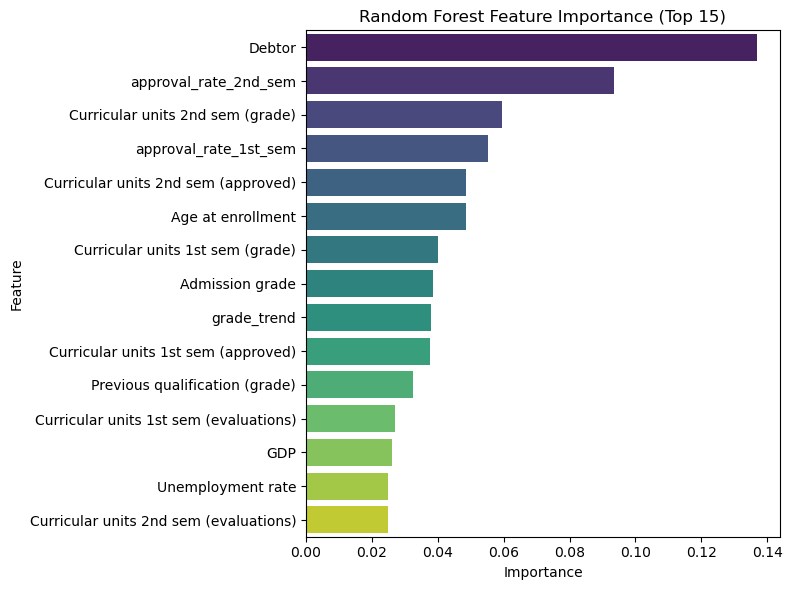

<Figure size 640x480 with 0 Axes>

In [72]:
importances.index.name = "Feature"

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, hue=importances.head(15).index, palette="viridis", legend=False)
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.savefig("visuals/feature_importance.png", bbox_inches="tight")
plt.show()

In [41]:
print(len(feature_cols))
print(feature_cols)

40
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'approval_rate_1st_sem', 'zero_units_1st_sem'

## 11. Explainability with SHAP
Feature importance shows *what* matters globally; SHAP shows *why* one specific student's prediction came out the way it did.

In [42]:
!pip install shap

In [43]:
import shap
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap_values

array([[[-0.00086408,  0.00086408],
        [ 0.00255864, -0.00255864],
        [-0.0016069 ,  0.0016069 ],
        ...,
        [-0.0033985 ,  0.0033985 ],
        [-0.06050723,  0.06050723],
        [-0.00379662,  0.00379662]],

       [[ 0.0004294 , -0.0004294 ],
        [-0.00268509,  0.00268509],
        [ 0.00172038, -0.00172038],
        ...,
        [-0.00026679,  0.00026679],
        [ 0.03696603, -0.03696603],
        [ 0.0336723 , -0.0336723 ]],

       [[ 0.0013488 , -0.0013488 ],
        [-0.00085639,  0.00085639],
        [ 0.00740912, -0.00740912],
        ...,
        [-0.00035315,  0.00035315],
        [ 0.07485277, -0.07485277],
        [-0.00101591,  0.00101591]],

       ...,

       [[ 0.00158607, -0.00158607],
        [ 0.00109191, -0.00109191],
        [-0.00104371,  0.00104371],
        ...,
        [-0.00039752,  0.00039752],
        [ 0.09414701, -0.09414701],
        [ 0.00603634, -0.00603634]],

       [[ 0.01337118, -0.01337118],
        [ 0.000228  , -0.00

In [44]:
shap_values.shape

(885, 40, 2)

In [45]:
sv = shap_values[:, :, 1]
sv.shape   

(885, 40)

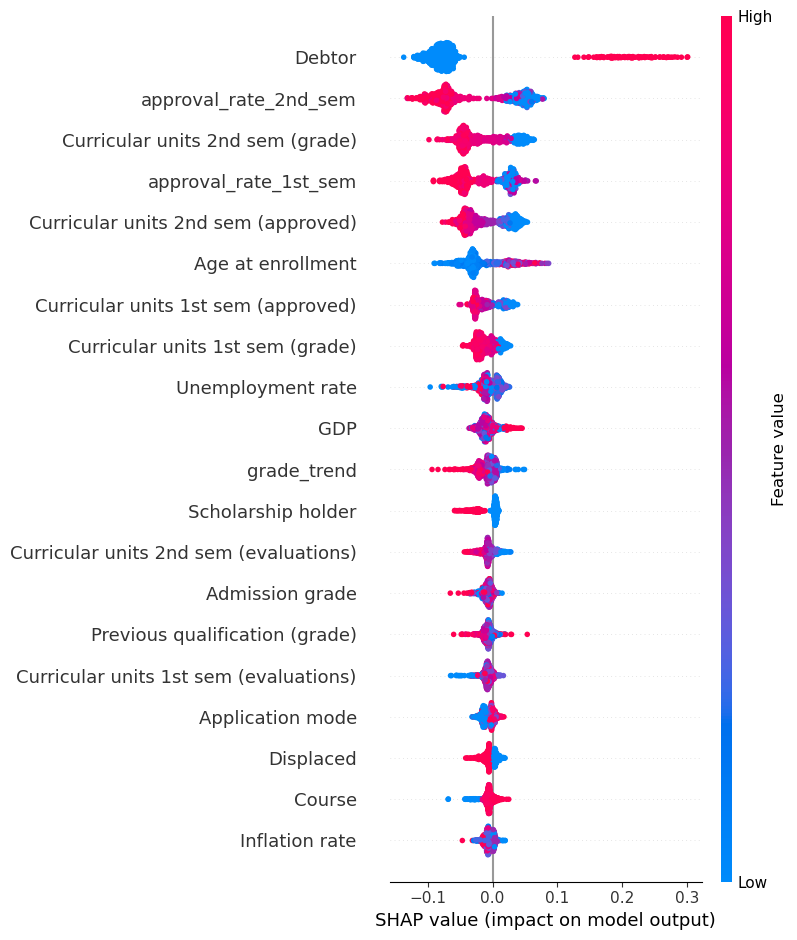

<Figure size 640x480 with 0 Axes>

In [73]:
shap.summary_plot(sv, X_test, feature_names=feature_cols)
plt.tight_layout()
plt.savefig("visuals/shap_summary.png", bbox_inches="tight")
plt.show()

Debtor shows the cleanest split in the entire plot — students already flagged as debtors cluster tightly toward higher default risk, with almost no overlap against non-debtors. This matches what we found manually in EDA before any model was trained, which is a good sign the model learned a real pattern rather than noise.

approval_rate_2nd_sem shows the inverse relationship: high approval rates (red) push toward "Current," low approval rates (blue) push toward "Defaulted." This makes intuitive sense — students who are struggling academically are also more likely to fall behind financially, whether because the same underlying stress (family circumstances, time pressure) affects both, or because academic struggle itself creates financial strain (e.g. delayed graduation, lost scholarship eligibility).

Age at enrollment shows a much weaker, noisier signal than Debtor — older students lean slightly toward higher default risk, but there's real overlap between the two groups near the center, meaning age alone doesn't cleanly separate defaulters from non-defaulters the way Debtor does.

Also, colour doesn't have a fixed meaning across rows. It's "high value of that specific feature," and whether high is risky or safe depends entirely on which feature you're looking at (e.g. red means risk for Debtor but red means safety for approval rate).

In [47]:
# Pick one student from the test set (index 0, for example)
student_idx = 0

student_shap = sv[student_idx]  # SHAP values for this one student, across all 40 features

# Pair each feature name with its SHAP value, sort by absolute value (magnitude matters, not sign)
top_factors = sorted(
    zip(feature_cols, student_shap),
    key=lambda x: abs(x[1]),
    reverse=True
)[:3]

for name, value in top_factors:
    direction = "increases risk" if value > 0 else "decreases risk"
    print(f"{name}: {direction} (SHAP value: {value:.4f})")

Debtor: decreases risk (SHAP value: -0.0739)
approval_rate_2nd_sem: increases risk (SHAP value: 0.0605)
Curricular units 2nd sem (grade): increases risk (SHAP value: 0.0584)


In [48]:
X_test.iloc[student_idx][["Debtor", "approval_rate_2nd_sem", "Curricular units 2nd sem (grade)"]]

Debtor                              0.0
approval_rate_2nd_sem               0.0
Curricular units 2nd sem (grade)    0.0
Name: 2504, dtype: float64

In [49]:
rf.predict_proba(X_test)[student_idx]

array([0.33145471, 0.66854529])

## 12. AI-Powered Feature: Personalized Fee-Recovery Suggestions

Two layers: a rule-based explanation (SHAP-driven, identifies top factors for one student) and an LLM layer (Groq API) that turns those factors into an actionable recommendation.

In [50]:
def explain_prediction(student_idx, sv, feature_cols, X_test, top_n=3):
    student_shap = sv[student_idx]
    top_factors = sorted(
        zip(feature_cols, student_shap),
        key=lambda x: abs(x[1]),
        reverse=True
    )[:top_n]

    result = []
    for name, shap_val in top_factors:
        actual_value = X_test.iloc[student_idx][name]
        direction = "increases risk" if shap_val > 0 else "decreases risk"
        result.append((name, actual_value, direction))
    return result

In [51]:
factors = explain_prediction(0, sv, feature_cols, X_test)
factors

[('Debtor', np.float64(0.0), 'decreases risk'),
 ('approval_rate_2nd_sem', np.float64(0.0), 'increases risk'),
 ('Curricular units 2nd sem (grade)', np.float64(0.0), 'increases risk')]

In [60]:
def prettify(name):
    return name.replace("_", " ").capitalize()

In [61]:
def template_advisory(risk_score, top_factors):
    if risk_score >= 0.6:
        risk_band = "high"
    elif risk_score >= 0.35:
        risk_band = "moderate"
    else:
        risk_band = "low"

    risk_factors = [prettify(name) for name, value, direction in top_factors if direction == "increases risk"]
    protective_factors = [prettify(name) for name, value, direction in top_factors if direction == "decreases risk"]

    text = f"This student shows a {risk_band} default risk ({risk_score:.0%}). "
    if risk_factors:
        text += f"Risk factors: {', '.join(risk_factors)}. "
    if protective_factors:
        text += f"Protective factors: {', '.join(protective_factors)}. "

    text += (
        "Suggested action: reach out before the next payment deadline to discuss "
        "a structured installment plan, and flag for the financial aid office if "
        "attendance or academic performance continues to decline."
    )
    return text

In [62]:
print(template_advisory(risk_score, factors))

This student shows a high default risk (67%). Risk factors: Approval rate 2nd sem, Curricular units 2nd sem (grade). Protective factors: Debtor. Suggested action: reach out before the next payment deadline to discuss a structured installment plan, and flag for the financial aid office if attendance or academic performance continues to decline.


In [63]:
prettify("Debtor")

'Debtor'

In [64]:
print(prettify("GDP"))

Gdp


In [65]:
def prettify(name):
    if "_" in name and name.islower():
        return name.replace("_", " ").capitalize()
    return name

In [66]:
print(prettify("GDP"))                        # should now print "GDP"
print(prettify("approval_rate_2nd_sem"))       # should still print "Approval rate 2nd sem"

GDP
Approval rate 2nd sem


In [78]:
import os
os.environ["GROQ_API_KEY"] = "YOUR_API_KEY"

In [79]:
import os
print("GROQ_API_KEY" in os.environ)

True


In [69]:
!pip install groq

In [80]:
from groq import Groq

def generate_advisory(risk_score, top_factors_with_values):
    api_key = os.environ.get("GROQ_API_KEY")

    factor_text = "; ".join(
        f"{name} = {value} ({direction})" for name, value, direction in top_factors_with_values
    )

    if not api_key:
        return template_advisory(risk_score, [(n, d) for n, v, d in top_factors_with_values]) + "\n\n[No GROQ_API_KEY set — showing rule-based fallback.]"

    try:
        client = Groq(api_key=api_key)
        prompt = (
            f"A student has a fee-default risk score of {risk_score:.0%}. "
            f"Top contributing factors, with this student's actual values: {factor_text}. "
            f"Note: grades in this dataset are on a 0-20 scale (not a 4.0 GPA), "
            f"and approval_rate is a fraction between 0 and 1. "
            f"Write a 2-3 sentence recommendation for a school financial admin — "
            f"specific and actionable, grounded only in the values given, not invented numbers."
        )
        response = client.chat.completions.create(
            model="openai/gpt-oss-20b",
            messages=[{"role": "user", "content": prompt}],
        )
        return response.choices[0].message.content
    except Exception as e:
        return template_advisory(risk_score, [(n, d) for n, v, d in top_factors_with_values]) + f"\n\n[LLM call failed ({e}) — showing rule-based fallback.]"

In [81]:
print(generate_advisory(risk_score, factors))

The student’s zero approval rate and zero grades in the second‑semester curricular units are major contributors to their 67 % fee‑default risk. Recommend an academic‑support intervention for the second semester—such as tutoring or a structured study plan—together with a customized payment plan that acknowledges the student’s current performance gap while leveraging the fact that the student is not a debtor. These steps can help improve their academic standing and reduce future payment risk.


## 13. Save Model Artifacts for Deployment

In [82]:
import joblib

joblib.dump(rf, "rf_model.pkl")
joblib.dump(feature_cols, "feature_cols.pkl")
joblib.dump(chosen_threshold, "threshold.pkl")

print("Saved.")

Saved.


In [83]:
defaults = students[feature_cols].median(numeric_only=True).to_dict()
# For a few known categorical columns, mode is more sensible than median:
for col in ["Marital status", "Application mode", "Course", "Nacionality",
            "Mother's qualification", "Father's qualification",
            "Mother's occupation", "Father's occupation", "Application order",
            "Previous qualification"]:
    defaults[col] = students[col].mode()[0]

joblib.dump(defaults, "defaults.pkl")
print("Saved defaults.pkl")

Saved defaults.pkl


## 14. Conclusions

- Tuned Random Forest (threshold 0.456) was selected for deployment — it beats both the Decision Tree and the default-threshold Random Forest on every metric (F1, precision, recall) for the defaulter class.
- `Debtor` status, semester approval rates, and admission grade are the strongest predictors.
- The GenAI layer required real debugging, not just wiring up an API call — grounding the prompt in actual values, decoding categorical codes, and explicitly constraining the model against speculation were all necessary to get trustworthy output.

**Next steps:** validate on a real Nigerian institution's data before using these specific feature weights and threshold to drive real intervention decisions — the pipeline transfers, but the learned patterns are specific to this Portuguese population.